# Hyperparameter Tuning — Illustrated

Three search strategies on a synthetic 2-D HP landscape:

1. **Grid search** — exhaustive on a regular mesh.
2. **Random search** — uniform random sampling.
3. **Bayesian optimisation (TPE)** — fit a surrogate, sample where it expects to improve.

Plus a **sensitivity** view: which HPs actually matter?


## The picture — grid vs random: random covers each axis better when most HPs do not matter

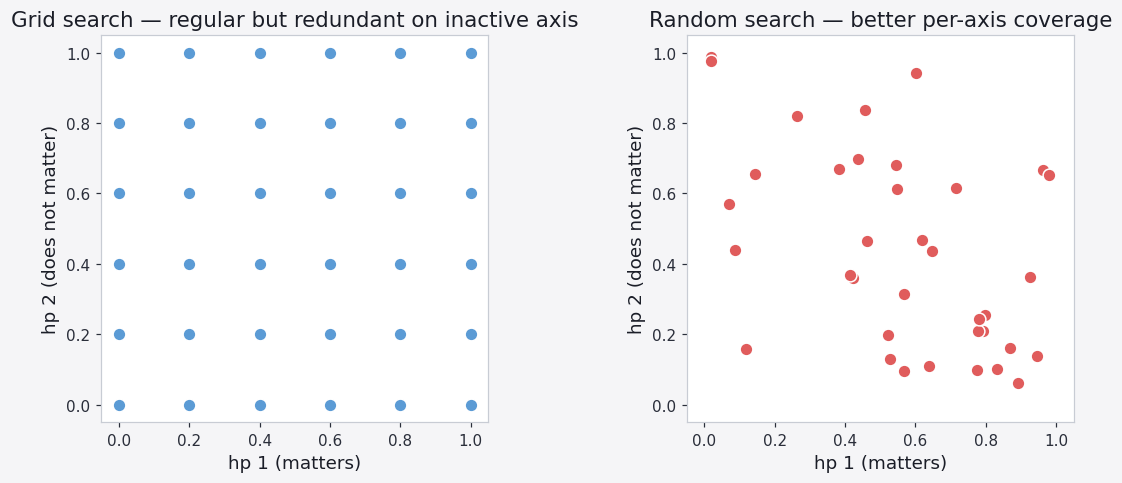

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
gx, gy = np.meshgrid(np.linspace(0,1,6), np.linspace(0,1,6))
ax.scatter(gx, gy, s=70, color=P[0], edgecolor='white')
ax.set_title('Grid search — regular but redundant on inactive axis')
ax = axes[1]
ax.scatter(rng.uniform(0,1,36), rng.uniform(0,1,36), s=70, color=P[1], edgecolor='white')
ax.set_title('Random search — better per-axis coverage')
for a in axes:
    a.set_aspect('equal'); a.set_xlim(-0.05, 1.05); a.set_ylim(-0.05, 1.05)
    a.set_xlabel('hp 1 (matters)'); a.set_ylabel('hp 2 (does not matter)')
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Pretend hyperparameters: log-learning-rate and weight-decay-strength.
# True validation score has a narrow ridge — most random points miss it.
def objective_landscape(lr, wd):
    return -((lr - 1.5)**2 + 0.2*(wd + 1.0)**2 + 0.4*np.sin(3*lr)*np.cos(3*wd))

LR  = np.linspace(-1, 4, 200)
WD  = np.linspace(-3, 1, 200)
LL, WW = np.meshgrid(LR, WD)
Z      = objective_landscape(LL, WW)
print('HP landscape ready (max ~ {:.2f})'.format(Z.max()))


HP landscape ready (max ~ 0.22)


---
## Three strategies, same budget

Each method gets 30 evaluations.


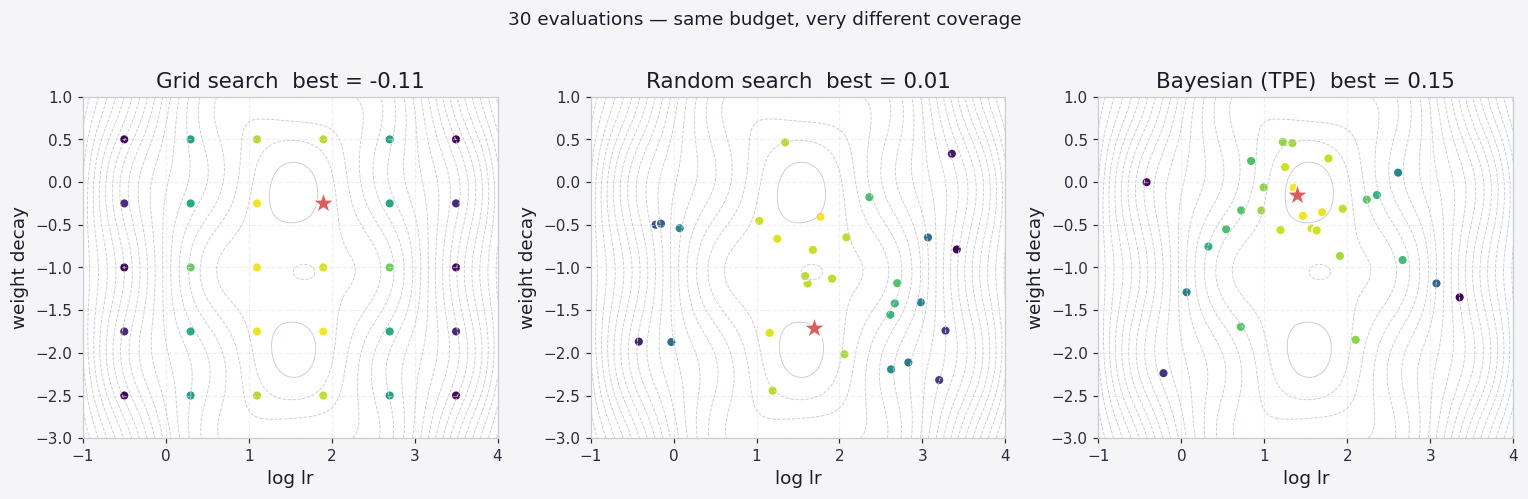

In [3]:
rng = np.random.RandomState(0)
budget = 30

# 1. Grid search (5x6 = 30)
gx, gy = np.meshgrid(np.linspace(-0.5, 3.5, 6), np.linspace(-2.5, 0.5, 5))
grid_pts = np.column_stack([gx.ravel(), gy.ravel()])
grid_scores = np.array([objective_landscape(p[0], p[1]) for p in grid_pts])

# 2. Random search
rand_pts = np.column_stack([rng.uniform(-0.5, 3.5, budget),
                            rng.uniform(-2.5, 0.5, budget)])
rand_scores = np.array([objective_landscape(p[0], p[1]) for p in rand_pts])

# 3. Bayesian (Optuna TPE)
def obj(trial):
    lr = trial.suggest_float('lr', -0.5, 3.5)
    wd = trial.suggest_float('wd', -2.5, 0.5)
    return -objective_landscape(lr, wd)

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(obj, n_trials=budget, show_progress_bar=False)
bo_pts    = np.array([[t.params['lr'], t.params['wd']] for t in study.trials])
bo_scores = np.array([-t.value for t in study.trials])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, pts, s, title in zip(
        axes,
        [grid_pts, rand_pts, bo_pts],
        [grid_scores, rand_scores, bo_scores],
        ['Grid search', 'Random search', 'Bayesian (TPE)']):
    ax.contour(LL, WW, Z, levels=20, colors='#c8ccd4', linewidths=0.6)
    sc = ax.scatter(pts[:,0], pts[:,1], c=s, cmap='viridis', s=40,
                    edgecolor='white')
    best = pts[int(np.argmax(s))]
    ax.scatter(best[0], best[1], marker='*', s=240, color='#e05c5c',
               edgecolor='white', zorder=5)
    ax.set_title(f'{title}  best = {s.max():.2f}')
    ax.set_xlabel('log lr'); ax.set_ylabel('weight decay')
    ax.grid(True)
fig.suptitle('30 evaluations — same budget, very different coverage', y=1.02)
plt.tight_layout(); plt.show()


---
## Convergence (best-so-far) curves


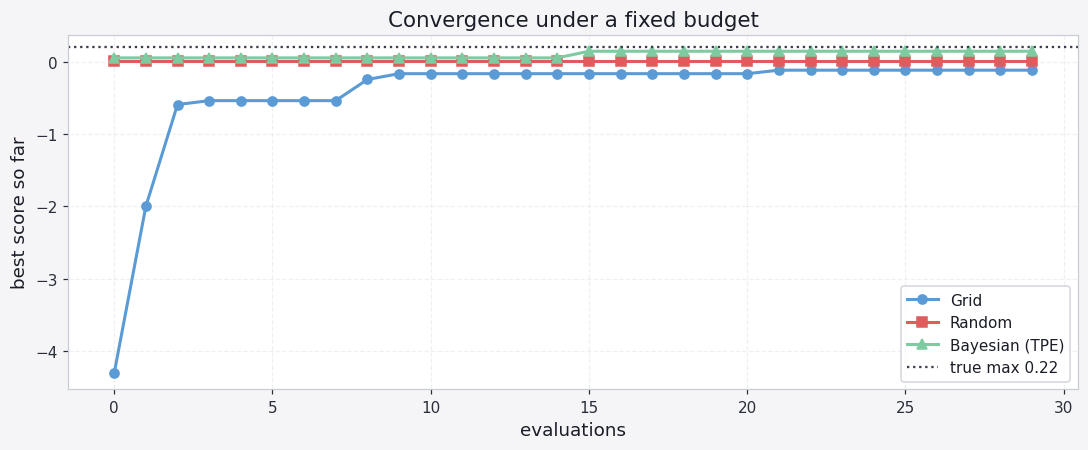

In [4]:
def best_so_far(s): return np.maximum.accumulate(s)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(best_so_far(grid_scores),  color=PALETTE[0], lw=2, marker='o', label='Grid')
ax.plot(best_so_far(rand_scores),  color=PALETTE[1], lw=2, marker='s', label='Random')
ax.plot(best_so_far(bo_scores),    color=PALETTE[3], lw=2, marker='^', label='Bayesian (TPE)')
ax.axhline(Z.max(), color='#3a3e4a', ls=':', label=f'true max {Z.max():.2f}')
ax.set_xlabel('evaluations'); ax.set_ylabel('best score so far')
ax.set_title('Convergence under a fixed budget'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


---
## Sensitivity — which HP actually matters?

Use Optuna's parameter importance (fANOVA on the surrogate).


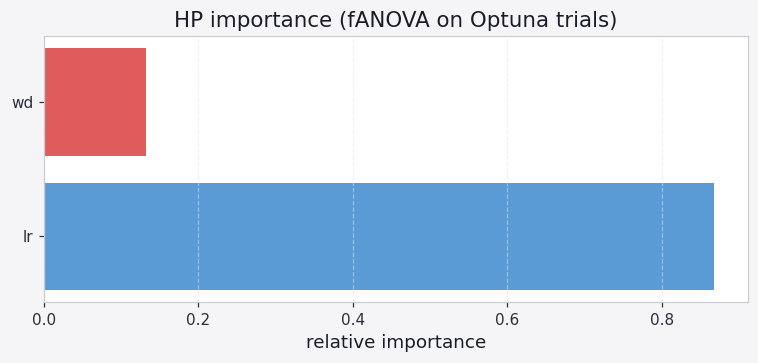

importance: {'lr': np.float64(0.87), 'wd': np.float64(0.13)}


In [5]:
importance = optuna.importance.get_param_importances(study)
fig, ax = plt.subplots(figsize=(7, 3.4))
names = list(importance.keys()); vals = list(importance.values())
ax.barh(names, vals, color=PALETTE[:len(names)])
ax.set_xlabel('relative importance')
ax.set_title('HP importance (fANOVA on Optuna trials)')
ax.grid(True, axis='x')
plt.tight_layout(); plt.show()
print('importance:', {k: round(v,2) for k,v in importance.items()})


---
## When to use what

- **Grid** — ≤2 HPs, you want reproducibility, want to draw a 2-D heatmap.
- **Random** — ≥3 HPs; usually beats grid because most HPs don't matter (Bergstra & Bengio, 2012).
- **Bayesian** — expensive evaluations (deep nets, large CV), small budgets, continuous HPs.
- **Hyperband / ASHA** — large budgets with cheap early-stop signal (epochs, iterations).

> Always **fix the seed** of the search and **never** retune on the test set. Tune on a held-out validation fold.
